# Diabetic Retinopathy Severity Classification — Basic Baseline

**Goal:** Classify retina fundus images into 5 severity grades:
`No_DR`, `Mild`, `Moderate`, `Severe`, `Proliferate_DR`.

**Dataset:** [Diabetic Retinopathy 2015 Data (Colored, Resized)](https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-2015-data-colored-resized)

This is the **basic version**. The aim here is to get a single, honest baseline working end-to-end:

1. Load the images from the 5 class folders.
2. Make a clean train / validation split.
3. Train **one** model (ResNet18) on **one** GPU with a simple training loop.
4. Look at accuracy + a confusion matrix.

We deliberately keep it simple. In the **advanced notebook** we improve on every weak point we find here: class imbalance, single-model fragility, no interpretability, and leaving the second T4 GPU idle.

## 1. Imports & setup

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPUs available:", torch.cuda.device_count())
# Note: Kaggle gives us 2x T4. The basic notebook only uses ONE of them.
# We fix that in the advanced notebook.

Using device: cuda
GPUs available: 2


## 2. Find the data

The Kaggle dataset mounts under `/kaggle/input/`. The images live in `colored_images/` with one sub-folder per class.

In [2]:
# Adjust if your input path differs (check the right sidebar 'Input' panel on Kaggle)
DATA_DIR = Path("/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset")

# Fallback: search for it automatically if the exact path changed
if not DATA_DIR.exists():
    for root, dirs, _ in os.walk("/kaggle/input"):
        if "colored_images" in dirs:
            DATA_DIR = Path(root) / "colored_images"
            break

print("Data dir:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

CLASSES = ["No_DR", "Mild", "Moderate", "Severe", "Proliferate_DR"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
print("Classes:", class_to_idx)

Data dir: /kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset
Exists: True
Classes: {'No_DR': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3, 'Proliferate_DR': 4}


In [3]:
# Build a dataframe of (filepath, label)
rows = []
for cls in CLASSES:
    folder = DATA_DIR / cls
    if not folder.exists():
        print("WARNING: missing folder", folder)
        continue
    for f in folder.glob("*"):
        if f.suffix.lower() in {".png", ".jpg", ".jpeg"}:
            rows.append({"path": str(f), "label": class_to_idx[cls], "class": cls})

df = pd.DataFrame(rows)
print("Total images:", len(df))
df["class"].value_counts()

Total images: 3554


class
Proliferate_DR    1089
No_DR              968
Severe             575
Mild               527
Moderate           395
Name: count, dtype: int64

## 3. Look at the class balance

Notice the imbalance straight away: `Proliferate_DR` and `No_DR` have ~1000 images each, while `Moderate` has ~395. A naive model will lean toward the big classes. We just *observe* this here — the basic model does nothing about it.

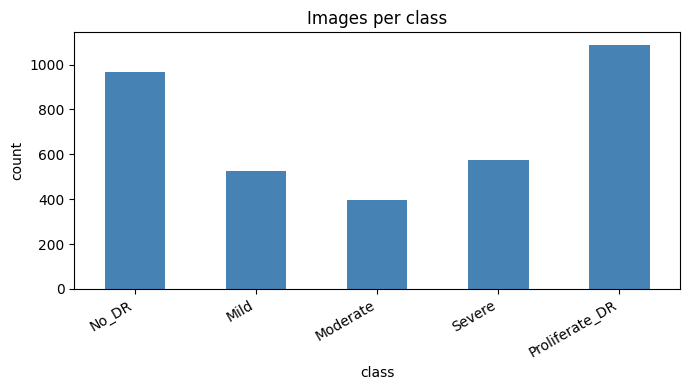

class
No_DR              968
Mild               527
Moderate           395
Severe             575
Proliferate_DR    1089
Name: count, dtype: int64


In [4]:
counts = df["class"].value_counts().reindex(CLASSES)
plt.figure(figsize=(7,4))
counts.plot(kind="bar", color="steelblue")
plt.title("Images per class")
plt.ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(counts)

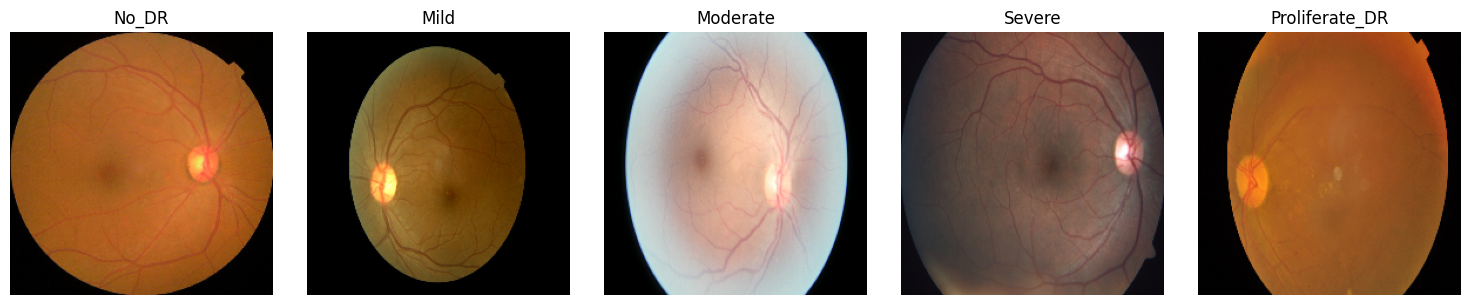

In [5]:
# Peek at a few sample images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, cls in zip(axes, CLASSES):
    sample = df[df["class"] == cls].iloc[0]
    img = Image.open(sample["path"])
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Train / validation split

A simple **stratified** 80/20 split so both sets keep the same class proportions.

In [6]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)
print("Train:", len(train_df), " Val:", len(val_df))

Train: 2843  Val: 711


## 5. Dataset & transforms

Standard ImageNet normalization. Resize to 224x224. Only light augmentation on the training set.

In [7]:
IMG_SIZE = 224
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class RetinaDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        img = self.transform(img)
        return img, row["label"]

train_ds = RetinaDataset(train_df, train_tf)
val_ds   = RetinaDataset(val_df, val_tf)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Batches:", len(train_loader), "train /", len(val_loader), "val")

Batches: 89 train / 23 val


## 6. The model — a single ResNet18

We use one pretrained ResNet18 and replace the final layer with a 5-class head. Nothing fancy. One model, one GPU.

In [8]:
def build_resnet18(num_classes=5):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

model = build_resnet18().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Model ready: ResNet18")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s] 


Model ready: ResNet18


## 7. Training loop

A plain loop: train one epoch, evaluate, repeat. We track loss and accuracy.

In [9]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            n += imgs.size(0)
    return total_loss / n, correct / n

In [10]:
EPOCHS = 8
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    va_loss, va_acc = run_epoch(model, val_loader, train=False)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val_loss {va_loss:.3f} acc {va_acc:.3f} | "
          f"{time.time()-t0:.0f}s")

Epoch 1/8 | train_loss 0.144 acc 0.960 | val_loss 0.032 acc 0.990 | 21s
Epoch 2/8 | train_loss 0.028 acc 0.995 | val_loss 0.027 acc 0.992 | 10s
Epoch 3/8 | train_loss 0.022 acc 0.993 | val_loss 0.033 acc 0.992 | 10s
Epoch 4/8 | train_loss 0.009 acc 0.998 | val_loss 0.018 acc 0.994 | 10s
Epoch 5/8 | train_loss 0.010 acc 0.996 | val_loss 0.026 acc 0.993 | 10s
Epoch 6/8 | train_loss 0.014 acc 0.996 | val_loss 0.032 acc 0.993 | 10s
Epoch 7/8 | train_loss 0.007 acc 0.998 | val_loss 0.042 acc 0.990 | 10s
Epoch 8/8 | train_loss 0.011 acc 0.996 | val_loss 0.024 acc 0.993 | 11s


## 8. Training curves

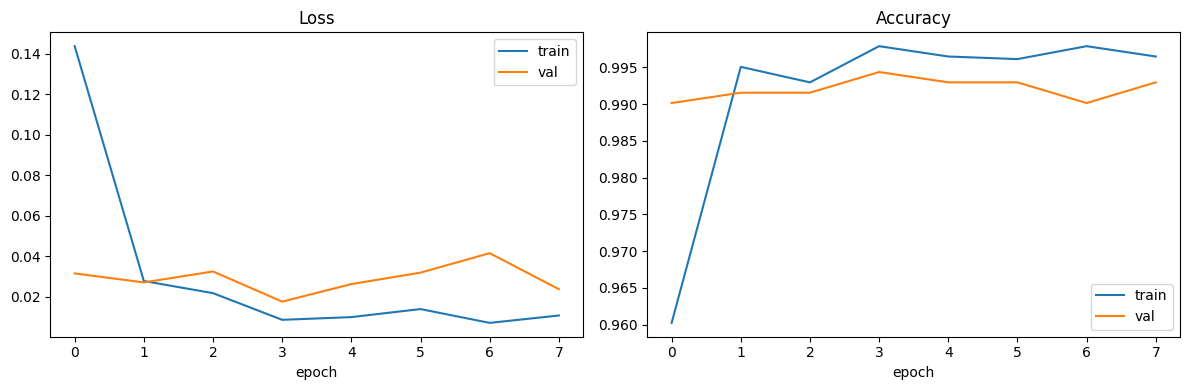

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Evaluation — confusion matrix & report

Where does the model actually fail? With imbalance and a single model, expect the minority classes (`Moderate`, `Severe`) to suffer.

                precision    recall  f1-score   support

         No_DR       0.99      1.00      1.00       194
          Mild       0.99      0.99      0.99       105
      Moderate       0.99      1.00      0.99        79
        Severe       0.98      0.99      0.99       115
Proliferate_DR       1.00      0.99      0.99       218

      accuracy                           0.99       711
     macro avg       0.99      0.99      0.99       711
  weighted avg       0.99      0.99      0.99       711



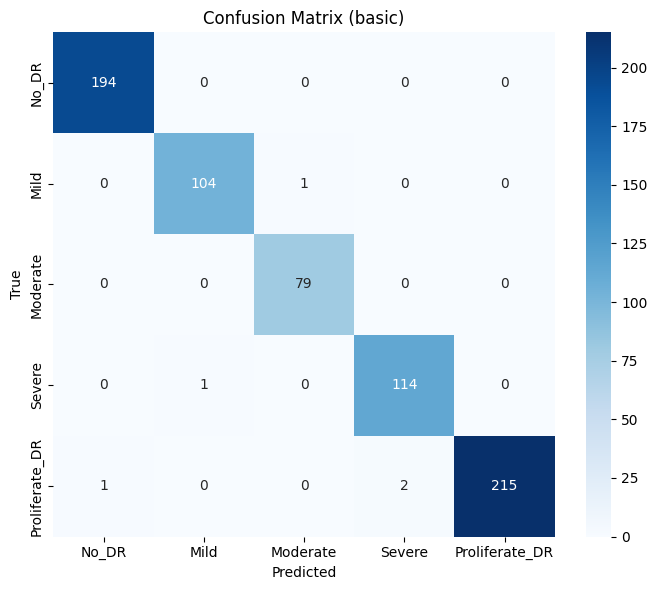

In [12]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (basic)")
plt.tight_layout(); plt.show()

## 10. Save the model

In [13]:
torch.save(model.state_dict(), "resnet18_basic.pth")
print("Saved resnet18_basic.pth")

Saved resnet18_basic.pth
